# Exploratory Time-Series Analysis

## Appliance Energy Forecasting

This notebook investigates the temporal structure of hourly appliance energy consumption before forecasting models are developed.

The analysis focuses on:

- descriptive characteristics of appliance energy use;
- the distribution of the target variable;
- short-term and long-term temporal behaviour;
- hour-of-day and day-of-week patterns;
- daily and weekly seasonality;
- autocorrelation and partial autocorrelation;
- time-series decomposition;
- stationarity testing;
- differencing where required.

The findings from this exploratory analysis will be used to justify the forecasting models and seasonal assumptions used in subsequent stages.

In [1]:
# Load and validate the hourly dataset

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [9]:
# Project paths

from pathlib import Path

# Change this path to your actual project folder
PROJECT_ROOT = Path(
    r"C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting"
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILE = (
    PROCESSED_DIR
    / "appliance_energy_hourly.csv"
)

print("Project root:", PROJECT_ROOT)
print("Processed directory:", PROCESSED_DIR)
print("Figure directory:", FIGURE_DIR)
print("Data file:", DATA_FILE)

print("\nProject root exists:", PROJECT_ROOT.exists())
print("Data file exists:", DATA_FILE.exists())

Project root: C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting
Processed directory: C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting\data\processed
Figure directory: C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting\outputs\figures
Data file: C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting\data\processed\appliance_energy_hourly.csv

Project root exists: True
Data file exists: True


In [10]:
# Load processed data

hourly_data = pd.read_csv(
    DATA_FILE,
    index_col="date",
    parse_dates=True
)

hourly_data = hourly_data.sort_index()

print("Dataset shape:", hourly_data.shape)
print(
    "Date range:",
    hourly_data.index.min(),
    "to",
    hourly_data.index.max()
)

hourly_data.head()

Dataset shape: (3290, 28)
Date range: 2016-01-11 17:00:00 to 2016-05-27 18:00:00


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,55.000000,35.000000,19.890000,46.502778,19.200000,44.626528,19.790000,44.897778,18.932778,45.738750,17.166667,55.116667,6.586667,84.260000,17.177778,41.400000,18.150000,48.710556,17.016667,45.446667,6.308333,733.750000,92.000000,6.166667,53.416667,5.050000,26.823044,26.823044
2016-01-11 18:00:00,176.666667,51.666667,19.897778,45.879028,19.268889,44.438889,19.770000,44.863333,18.908333,46.066667,17.111111,54.977778,6.180000,87.204444,17.229583,42.046806,18.094444,48.597222,16.981667,45.290000,5.941667,734.266667,91.583333,5.416667,40.000000,4.658333,22.324206,22.324206
2016-01-11 19:00:00,173.333333,25.000000,20.495556,52.805556,19.925556,46.061667,20.052222,47.227361,18.969444,47.815556,17.136111,55.869861,5.857361,88.131389,17.850000,45.017778,18.156111,49.213333,16.902222,45.311389,6.000000,734.791667,89.750000,6.000000,40.000000,4.391667,33.734932,33.734932
2016-01-11 20:00:00,125.000000,35.000000,20.961111,48.453333,20.251111,45.632639,20.213889,47.268889,19.190833,49.227917,17.615556,74.027778,5.469444,86.933889,17.632222,42.920000,18.773333,50.195556,16.890000,45.118889,6.000000,735.283333,87.583333,6.000000,40.000000,4.016667,25.679642,25.679642
2016-01-11 21:00:00,103.333333,23.333333,21.311667,45.768333,20.587778,44.961111,20.373333,46.164444,19.425556,47.918889,18.427222,69.037778,5.578889,86.129444,17.863611,43.618333,19.153333,49.542222,16.890000,44.807778,5.833333,735.566667,87.416667,6.000000,40.000000,3.816667,18.826274,18.826274


In [11]:
# Validate the time-series structure

print("Number of observations:", len(hourly_data))

print(
    "Duplicate timestamps:",
    hourly_data.index.duplicated().sum()
)

print(
    "Missing target values:",
    hourly_data["Appliances"].isna().sum()
)

print(
    "Index sorted:",
    hourly_data.index.is_monotonic_increasing
)

print(
    "Inferred frequency:",
    pd.infer_freq(hourly_data.index)
)

Number of observations: 3290
Duplicate timestamps: 0
Missing target values: 0
Index sorted: True
Inferred frequency: h


##  Target Variable

The forecasting target is `Appliances`, representing appliance energy use.

Exploratory analysis is first performed on the target series to understand its distribution, variability, extreme observations, and temporal structure. These characteristics are important when selecting suitable benchmark, statistical, machine-learning, and foundation forecasting models.

In [12]:
# Descriptive statistics

target = hourly_data["Appliances"].copy()

target_summary = target.describe()

target_summary

count    3290.000000
mean       97.779129
std        81.213695
min        28.333333
25%        50.000000
50%        63.333333
75%       110.000000
max       608.333333
Name: Appliances, dtype: float64

In [13]:
# Additional target statistics

additional_statistics = pd.Series({
    "Variance": target.var(),
    "Skewness": target.skew(),
    "Kurtosis": target.kurt(),
    "Coefficient_of_variation": (
        target.std() / target.mean()
    )
})

additional_statistics

Variance                    6595.664184
Skewness                       2.388553
Kurtosis                       6.327237
Coefficient_of_variation       0.830583
dtype: float64

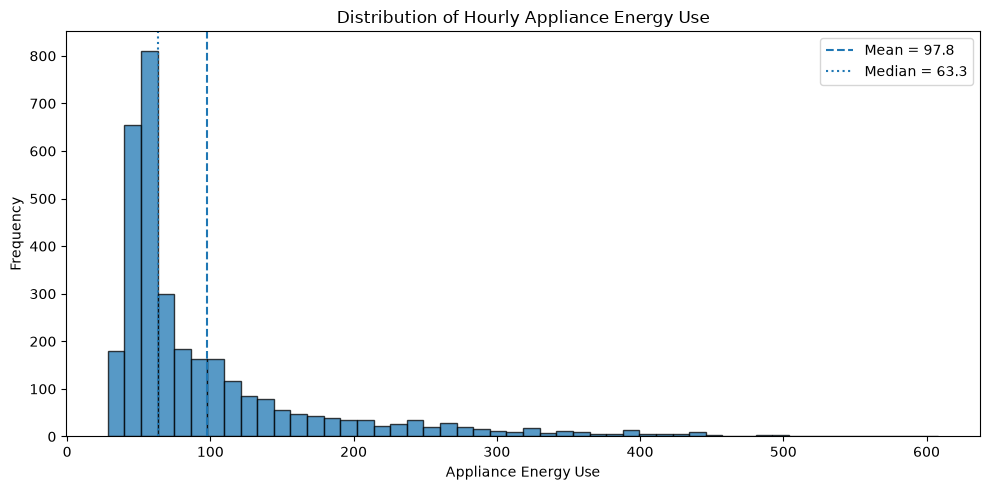

Figure saved to:
C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting\outputs\figures\02_target_distribution.png


In [14]:
# Target distribution

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    target,
    bins=50,
    edgecolor="black",
    alpha=0.75
)

ax.axvline(
    target.mean(),
    linestyle="--",
    linewidth=1.5,
    label=f"Mean = {target.mean():.1f}"
)

ax.axvline(
    target.median(),
    linestyle=":",
    linewidth=1.5,
    label=f"Median = {target.median():.1f}"
)

ax.set_title("Distribution of Hourly Appliance Energy Use")
ax.set_xlabel("Appliance Energy Use")
ax.set_ylabel("Frequency")
ax.legend()

fig.tight_layout()

figure_path = FIGURE_DIR / "02_target_distribution.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure_path)

C:\Users\LOJANA-UOH\AppData\Local\Temp\ipykernel_14996\1823256956.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


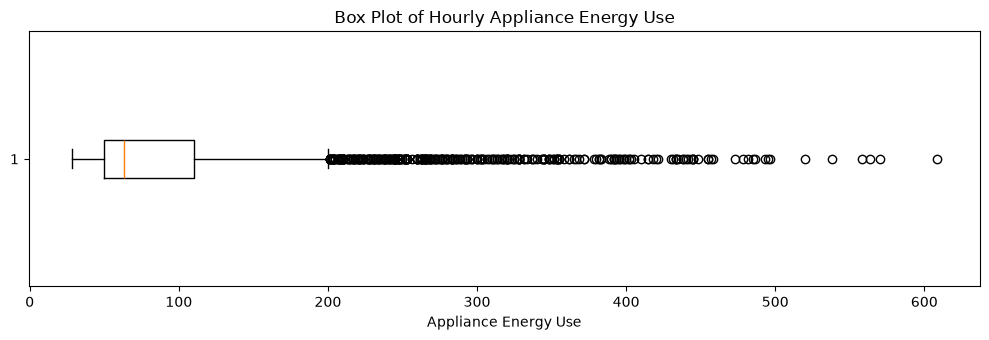

Figure saved to:
C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting\outputs\figures\03_target_boxplot.png


In [15]:
fig, ax = plt.subplots(figsize=(10, 3.5))

ax.boxplot(
    target.dropna(),
    vert=False
)

ax.set_title("Box Plot of Hourly Appliance Energy Use")
ax.set_xlabel("Appliance Energy Use")

fig.tight_layout()

figure_path = FIGURE_DIR / "03_target_boxplot.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure_path)

##  Temporal Patterns

The complete time series shows substantial short-term variation and numerous high-consumption episodes. To investigate whether systematic temporal patterns exist, the series is examined over shorter daily and weekly windows and aggregated by calendar features.

For hourly data, a daily seasonal cycle corresponds to 24 observations, while a weekly seasonal cycle corresponds to 168 observations.

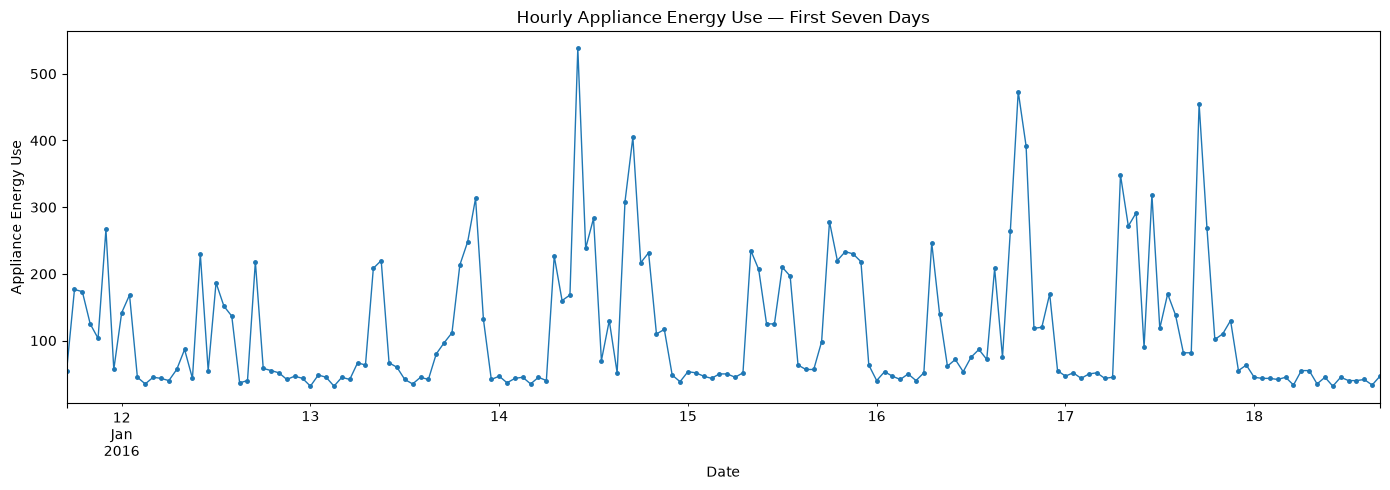

Figure saved to:
C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting\outputs\figures\04_first_week_appliance_energy.png


In [16]:
# First 7 Days

first_week = target.iloc[:24 * 7]

fig, ax = plt.subplots(figsize=(14, 5))

first_week.plot(
    ax=ax,
    marker="o",
    markersize=2.5,
    linewidth=1
)

ax.set_title(
    "Hourly Appliance Energy Use — First Seven Days"
)
ax.set_xlabel("Date")
ax.set_ylabel("Appliance Energy Use")

fig.tight_layout()

figure_path = (
    FIGURE_DIR /
    "04_first_week_appliance_energy.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure_path)

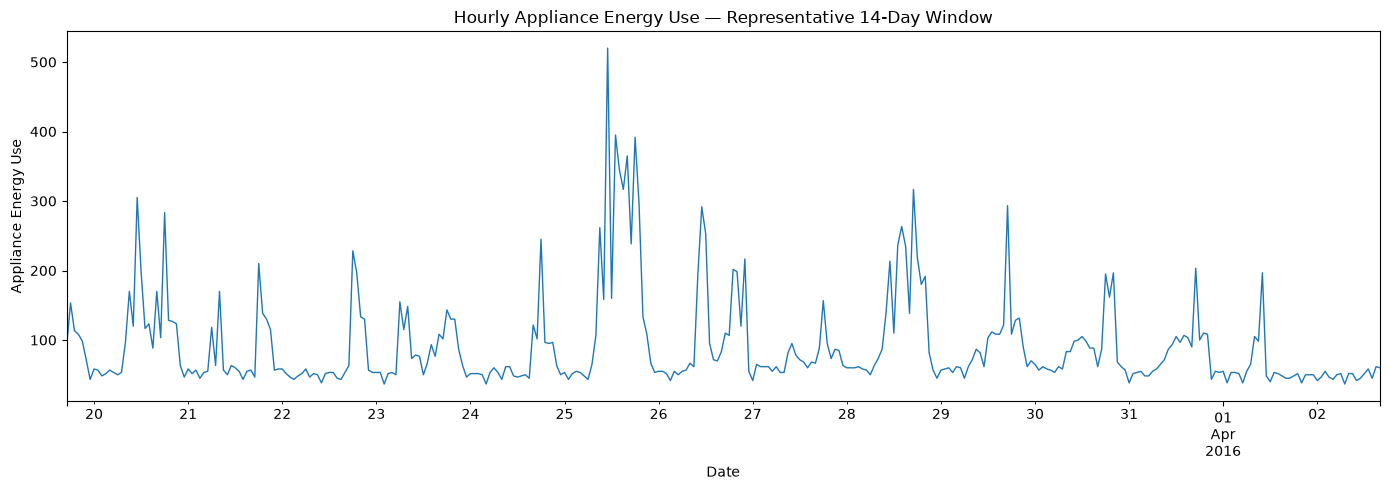

Figure saved to:
C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting\outputs\figures\05_fourteen_day_appliance_energy.png


In [17]:
# A representative 14-day window

middle_start = len(target) // 2

middle_start = middle_start - (
    middle_start % 24
)

two_week_window = target.iloc[
    middle_start:
    middle_start + (14 * 24)
]

fig, ax = plt.subplots(figsize=(14, 5))

two_week_window.plot(
    ax=ax,
    linewidth=1
)

ax.set_title(
    "Hourly Appliance Energy Use — Representative 14-Day Window"
)
ax.set_xlabel("Date")
ax.set_ylabel("Appliance Energy Use")

fig.tight_layout()

figure_path = (
    FIGURE_DIR /
    "05_fourteen_day_appliance_energy.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure_path)

In [18]:
# Create calendar variables

eda_data = hourly_data.copy()

eda_data["hour"] = eda_data.index.hour
eda_data["dayofweek"] = eda_data.index.dayofweek
eda_data["day_name"] = eda_data.index.day_name()
eda_data["month"] = eda_data.index.month
eda_data["is_weekend"] = (
    eda_data["dayofweek"] >= 5
).astype(int)

eda_data[
    [
        "Appliances",
        "hour",
        "dayofweek",
        "day_name",
        "is_weekend"
    ]
].head()

,Appliances,hour,dayofweek,day_name,is_weekend
date,,,,,
2016-01-11 17:00:00,55.000000,17,0,Monday,0
2016-01-11 18:00:00,176.666667,18,0,Monday,0
2016-01-11 19:00:00,173.333333,19,0,Monday,0
2016-01-11 20:00:00,125.000000,20,0,Monday,0
2016-01-11 21:00:00,103.333333,21,0,Monday,0


In [19]:
# Mean appliance use by hour

hourly_profile = (
    eda_data
    .groupby("hour")["Appliances"]
    .agg(["mean", "median", "std"])
)

hourly_profile

,mean,median,std
hour,,,
0,52.785888,51.666667,16.537625
1,51.326034,51.666667,12.452752
2,49.075426,50.000000,7.387278
3,48.236010,48.333333,7.751150
4,49.355231,50.000000,7.106359
5,52.737226,50.000000,16.441788
6,57.712895,51.666667,33.869467
7,78.649635,56.666667,56.332105
8,106.143552,73.333333,80.195011


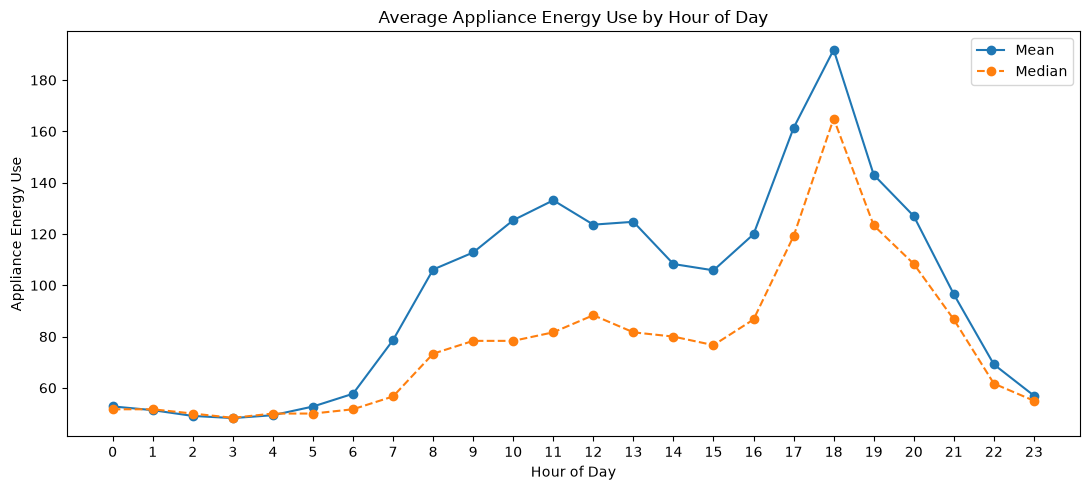

Figure saved to:
C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting\outputs\figures\06_hour_of_day_profile.png


In [20]:
# Plot hour-of-day pattern

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    hourly_profile.index,
    hourly_profile["mean"],
    marker="o",
    label="Mean"
)

ax.plot(
    hourly_profile.index,
    hourly_profile["median"],
    marker="o",
    linestyle="--",
    label="Median"
)

ax.set_title(
    "Average Appliance Energy Use by Hour of Day"
)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Appliance Energy Use")
ax.set_xticks(range(0, 24))
ax.legend()

fig.tight_layout()

figure_path = (
    FIGURE_DIR /
    "06_hour_of_day_profile.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure_path)

In [21]:
# Day-of-week statistics

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_profile = (
    eda_data
    .groupby("day_name")["Appliances"]
    .agg(["mean", "median", "std"])
    .reindex(day_order)
)

day_profile

,mean,median,std
day_name,,,
Monday,111.450684,63.333333,97.768089
Tuesday,87.125000,56.666667,70.256501
Wednesday,89.930556,68.333333,63.614144
Thursday,90.434028,58.333333,75.916439
Friday,105.192982,60.000000,92.891593
Saturday,106.246345,70.833333,86.684909
Sunday,94.915936,65.000000,73.314260


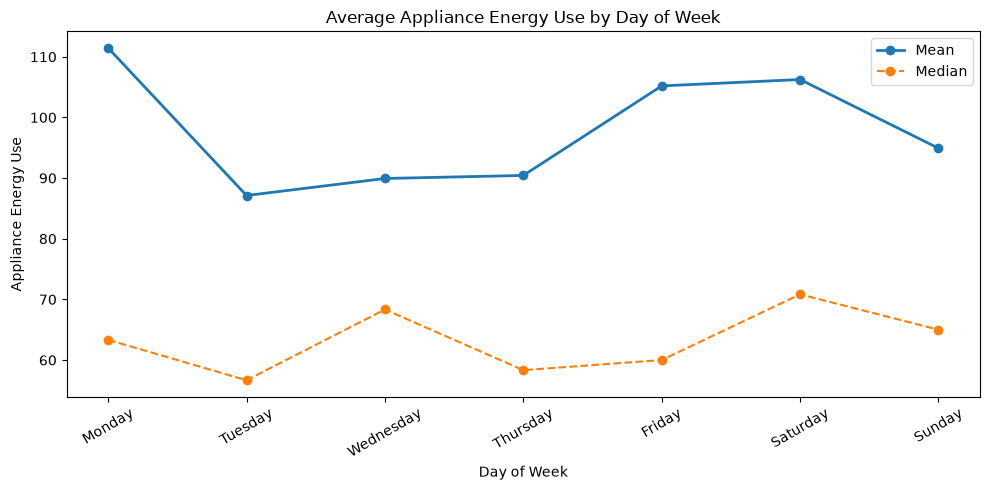

Figure saved to:
C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting\outputs\figures\07_day_of_week_profile.png


In [22]:
# Day-of-week plot

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    day_profile.index,
    day_profile["mean"],
    marker="o",
    linewidth=2,
    label="Mean"
)

ax.plot(
    day_profile.index,
    day_profile["median"],
    marker="o",
    linestyle="--",
    label="Median"
)

ax.set_title(
    "Average Appliance Energy Use by Day of Week"
)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Appliance Energy Use")

ax.tick_params(
    axis="x",
    rotation=30
)

ax.legend()

fig.tight_layout()

figure_path = (
    FIGURE_DIR /
    "07_day_of_week_profile.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure_path)

In [23]:
# Weekday vs weekend comparison

weekend_profile = (
    eda_data
    .groupby("is_weekend")["Appliances"]
    .agg(["mean", "median", "std", "count"])
)

weekend_profile.index = [
    "Weekday",
    "Weekend"
]

weekend_profile

,mean,median,std,count
Weekday,96.704514,61.666667,81.501868,2378
Weekend,100.581140,68.333333,80.434337,912


In [24]:
# Monthly profile

monthly_profile = (
    eda_data
    .groupby(eda_data.index.to_period("M"))[
        "Appliances"
    ]
    .agg(["mean", "median", "std", "count"])
)

monthly_profile

,mean,median,std,count
date,,,,
2016-01,97.026010,48.333333,97.369623,487
2016-02,100.945881,66.666667,79.437441,696
2016-03,96.953405,63.333333,79.434171,744
2016-04,98.888889,63.333333,83.405532,720
2016-05,94.634526,65.000000,68.300402,643


In [25]:
# Save the EDA summary tables

EDA_TABLE_DIR = (
    PROJECT_ROOT /
    "outputs" /
    "metrics"
)

EDA_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

hourly_profile.to_csv(
    EDA_TABLE_DIR /
    "eda_hourly_profile.csv"
)

day_profile.to_csv(
    EDA_TABLE_DIR /
    "eda_day_of_week_profile.csv"
)

weekend_profile.to_csv(
    EDA_TABLE_DIR /
    "eda_weekday_weekend_profile.csv"
)

monthly_profile.to_csv(
    EDA_TABLE_DIR /
    "eda_monthly_profile.csv"
)

print("EDA summary tables saved successfully.")

EDA summary tables saved successfully.


##  Rolling Statistics

Rolling mean and rolling standard deviation provide an initial visual assessment of stationarity.

A stationary time series is expected to maintain approximately constant mean and variance over time.

Although formal statistical tests are performed later, rolling statistics offer an intuitive first indication of whether these assumptions are likely to hold.

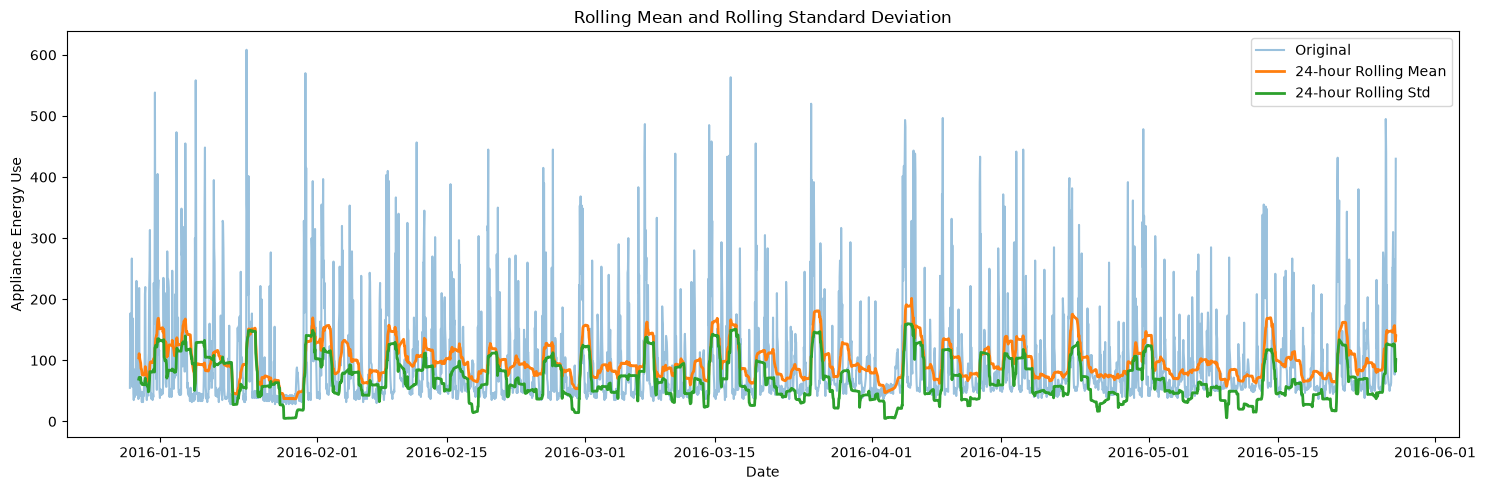

In [26]:
rolling_mean = target.rolling(window=24).mean()
rolling_std = target.rolling(window=24).std()

fig, ax = plt.subplots(figsize=(15,5))

ax.plot(
    target,
    label="Original",
    alpha=0.45
)

ax.plot(
    rolling_mean,
    linewidth=2,
    label="24-hour Rolling Mean"
)

ax.plot(
    rolling_std,
    linewidth=2,
    label="24-hour Rolling Std"
)

ax.set_title("Rolling Mean and Rolling Standard Deviation")
ax.set_xlabel("Date")
ax.set_ylabel("Appliance Energy Use")

ax.legend()

fig.tight_layout()

figure_path = FIGURE_DIR / "08_rolling_statistics.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##  Seasonal Decomposition

The hourly appliance energy series is decomposed into trend, seasonal, and residual components to examine whether a systematic daily pattern is present.

For hourly observations, a daily seasonal cycle corresponds to 24 observations. An additive decomposition is initially used to separate the observed series into trend, seasonal, and irregular components.

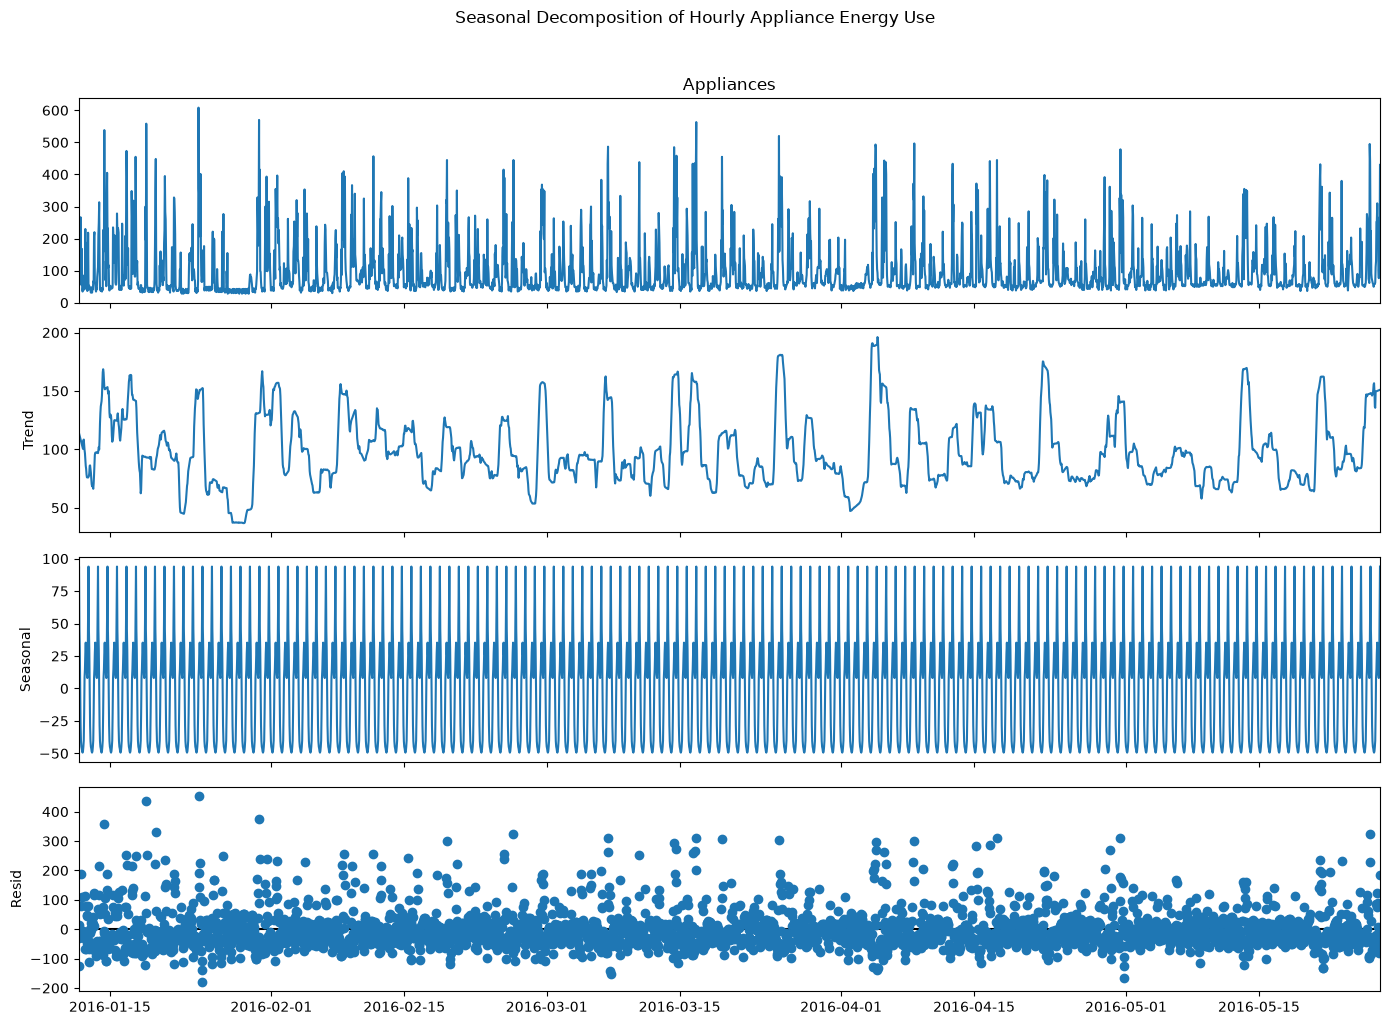

Figure saved to:
C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting\outputs\figures\09_daily_seasonal_decomposition.png


In [27]:
#  Daily seasonal decomposition

decomposition = seasonal_decompose(
    target,
    model="additive",
    period=24,
    extrapolate_trend="freq"
)

fig = decomposition.plot()
fig.set_size_inches(14, 10)

fig.suptitle(
    "Seasonal Decomposition of Hourly Appliance Energy Use",
    y=1.02
)

fig.tight_layout()

figure_path = (
    FIGURE_DIR /
    "09_daily_seasonal_decomposition.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure_path)

##  Autocorrelation Analysis

The autocorrelation function (ACF) measures the correlation between appliance energy use and its own lagged observations.

Significant autocorrelation at short lags indicates temporal dependence, while recurring peaks around seasonal lags such as 24 or 168 hours may indicate daily or weekly seasonal structure.

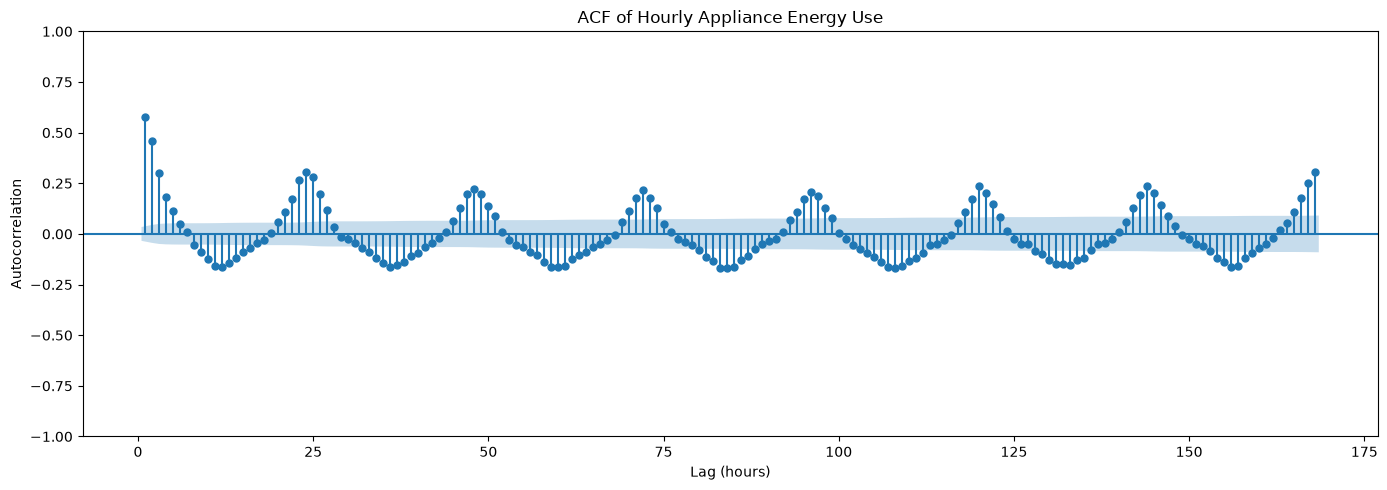

Figure saved to:
C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting\outputs\figures\10_acf_original_series.png


In [28]:
# ACF up to 7 days

fig, ax = plt.subplots(figsize=(14, 5))

plot_acf(
    target.dropna(),
    lags=24 * 7,
    ax=ax,
    zero=False
)

ax.set_title(
    "ACF of Hourly Appliance Energy Use"
)
ax.set_xlabel("Lag (hours)")
ax.set_ylabel("Autocorrelation")

fig.tight_layout()

figure_path = FIGURE_DIR / "10_acf_original_series.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure_path)

## Partial Autocorrelation Analysis

The partial autocorrelation function (PACF) measures the relationship between the current value and a lagged observation after controlling for the effects of intermediate lags.

The PACF can provide useful evidence about the autoregressive structure of the series and can assist later SARIMA model specification.

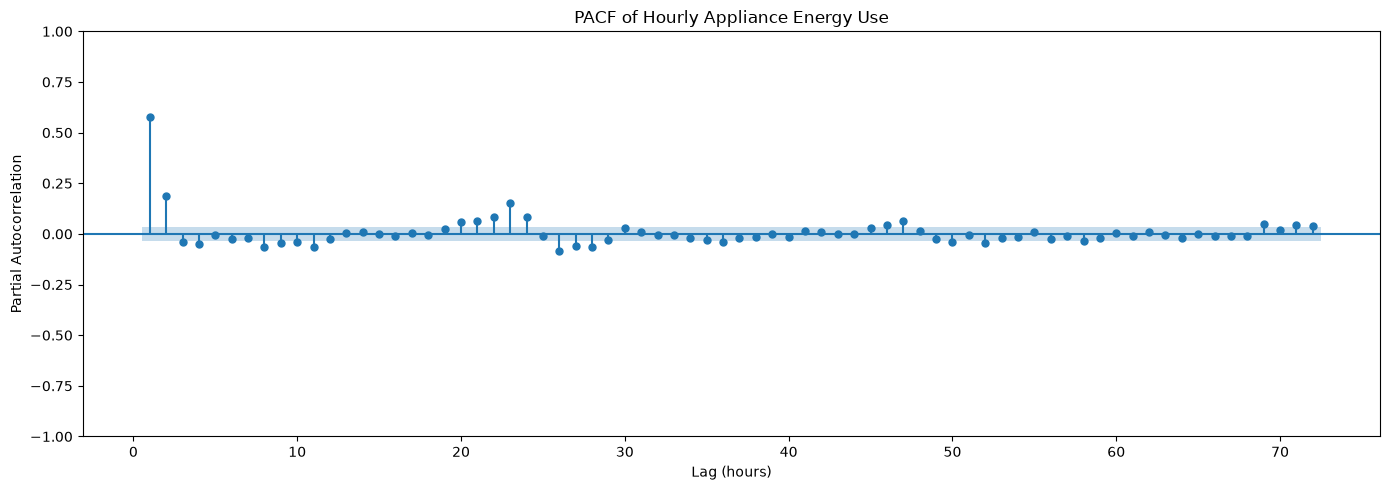

Figure saved to:
C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-02\Appliance-Energy-Forecasting\outputs\figures\11_pacf_original_series.png


In [29]:
fig, ax = plt.subplots(figsize=(14, 5))

plot_pacf(
    target.dropna(),
    lags=72,
    ax=ax,
    method="ywm",
    zero=False
)

ax.set_title(
    "PACF of Hourly Appliance Energy Use"
)
ax.set_xlabel("Lag (hours)")
ax.set_ylabel("Partial Autocorrelation")

fig.tight_layout()

figure_path = FIGURE_DIR / "11_pacf_original_series.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure_path)

##  Augmented Dickey–Fuller Test

The Augmented Dickey–Fuller (ADF) test is used to formally assess whether the appliance energy series contains a unit root.

The hypotheses are:

- **H0:** the series contains a unit root and is non-stationary;
- **H1:** the series is stationary.

A p-value below 0.05 provides evidence to reject the null hypothesis at the 5% significance level.

In [30]:
def run_adf_test(series, name="Series"):
    """
    Run the Augmented Dickey-Fuller stationarity test.

    Parameters
    ----------
    series : pd.Series
        Time series to test.
    name : str
        Name displayed in the output.

    Returns
    -------
    dict
        ADF statistic, p-value, lag information,
        number of observations, and critical values.
    """

    series = series.dropna()

    result = adfuller(
        series,
        autolag="AIC"
    )

    output = {
        "series": name,
        "ADF Statistic": result[0],
        "p-value": result[1],
        "Used Lags": result[2],
        "Observations": result[3],
        "Critical Value 1%": result[4]["1%"],
        "Critical Value 5%": result[4]["5%"],
        "Critical Value 10%": result[4]["10%"],
    }

    return output

In [31]:
adf_original = run_adf_test(
    target,
    name="Original hourly Appliances"
)

pd.Series(adf_original)

series                Original hourly Appliances
ADF Statistic                          -8.948888
p-value                                      0.0
Used Lags                                     29
Observations                                3260
Critical Value 1%                      -3.432358
Critical Value 5%                      -2.862427
Critical Value 10%                     -2.567242
dtype: object

##  KPSS Stationarity Test

The KPSS test is used as a complementary stationarity test because its null hypothesis differs from the ADF test.

The hypotheses are:

- **H0:** the series is stationary around a deterministic level;
- **H1:** the series is non-stationary.

Using both ADF and KPSS provides a more robust assessment than relying on a single statistical test.

In [32]:
def run_kpss_test(series, name="Series"):
    """
    Run the KPSS stationarity test.

    Parameters
    ----------
    series : pd.Series
        Time series to test.
    name : str
        Name displayed in the output.

    Returns
    -------
    dict
        KPSS statistic, p-value, number of lags,
        and critical values.
    """

    series = series.dropna()

    statistic, p_value, lags, critical_values = kpss(
        series,
        regression="c",
        nlags="auto"
    )

    output = {
        "series": name,
        "KPSS Statistic": statistic,
        "p-value": p_value,
        "Used Lags": lags,
        "Critical Value 10%": critical_values["10%"],
        "Critical Value 5%": critical_values["5%"],
        "Critical Value 2.5%": critical_values["2.5%"],
        "Critical Value 1%": critical_values["1%"],
    }

    return output

In [33]:
kpss_original = run_kpss_test(
    target,
    name="Original hourly Appliances"
)

pd.Series(kpss_original)

C:\Users\LOJANA-UOH\AppData\Local\Temp\ipykernel_14996\739042565.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, lags, critical_values = kpss(


series                 Original hourly Appliances
KPSS Statistic                           0.038399
p-value                                       0.1
Used Lags                                      25
Critical Value 10%                          0.347
Critical Value 5%                           0.463
Critical Value 2.5%                         0.574
Critical Value 1%                           0.739
dtype: object

##  Differencing

Differencing is examined to determine whether removing short-term or seasonal dependence improves stationarity.

Two transformations are investigated:

1. first-order differencing, which measures the change from one hour to the next;
2. seasonal differencing at lag 24, which compares each observation with the corresponding hour on the previous day.

The transformations are evaluated statistically before deciding whether differencing should be incorporated into SARIMA modelling.

In [34]:
# First difference

first_difference = target.diff().dropna()

first_difference.head()

date
2016-01-11 18:00:00    121.666667
2016-01-11 19:00:00     -3.333333
2016-01-11 20:00:00    -48.333333
2016-01-11 21:00:00    -21.666667
2016-01-11 22:00:00    163.333333
Name: Appliances, dtype: float64

In [35]:
# Seasonal difference

seasonal_difference = (
    target
    .diff(24)
    .dropna()
)

seasonal_difference.head()

date
2016-01-12 17:00:00    163.333333
2016-01-12 18:00:00   -118.333333
2016-01-12 19:00:00   -118.333333
2016-01-12 20:00:00    -73.333333
2016-01-12 21:00:00    -61.666667
Name: Appliances, dtype: float64

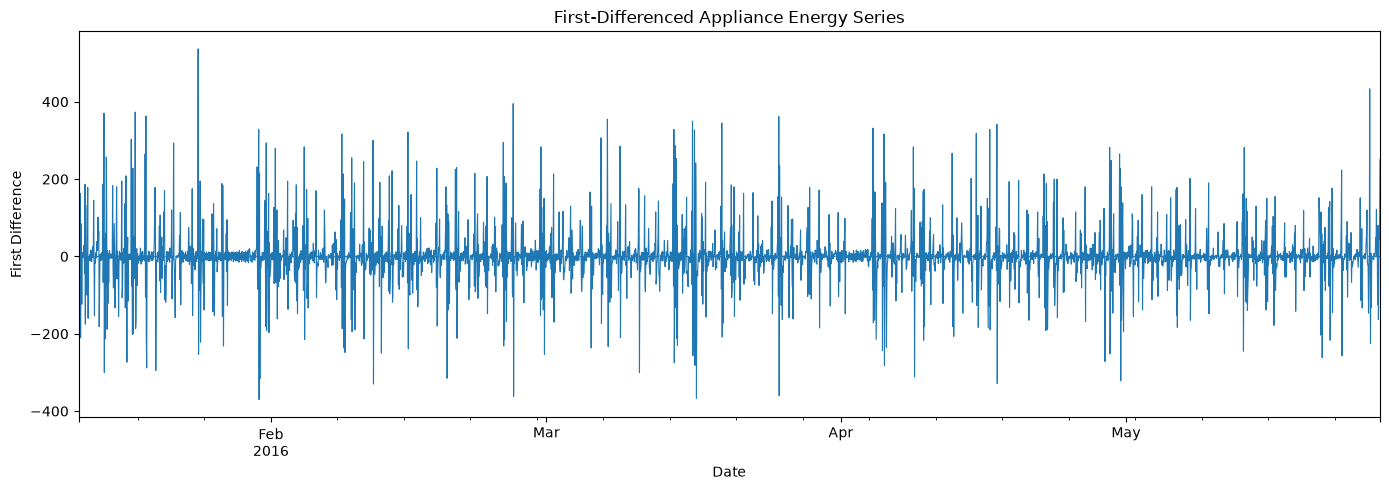

In [36]:
# Plot original and differenced series

fig, ax = plt.subplots(figsize=(14, 5))

first_difference.plot(
    ax=ax,
    linewidth=0.8
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "First-Differenced Appliance Energy Series"
)
ax.set_xlabel("Date")
ax.set_ylabel("First Difference")

fig.tight_layout()

figure_path = FIGURE_DIR / "12_first_difference.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

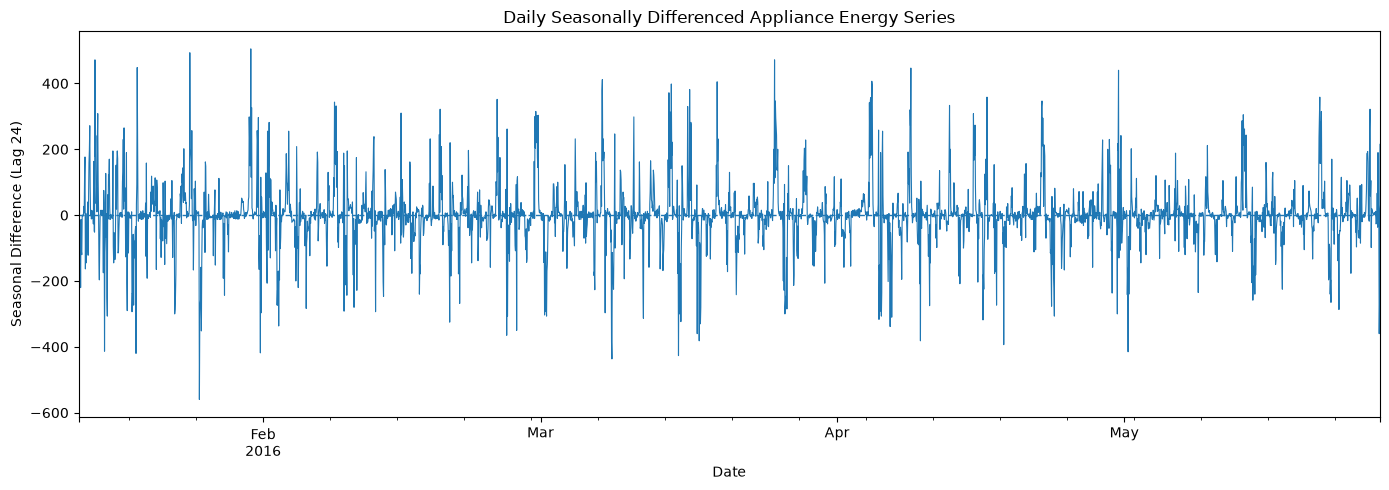

In [37]:
# seasonal difference

fig, ax = plt.subplots(figsize=(14, 5))

seasonal_difference.plot(
    ax=ax,
    linewidth=0.8
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Daily Seasonally Differenced Appliance Energy Series"
)
ax.set_xlabel("Date")
ax.set_ylabel("Seasonal Difference (Lag 24)")

fig.tight_layout()

figure_path = (
    FIGURE_DIR /
    "13_seasonal_difference_24.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
#  Re-test the transformed series

adf_first_diff = run_adf_test(
    first_difference,
    name="First-differenced Appliances"
)

adf_seasonal_diff = run_adf_test(
    seasonal_difference,
    name="Seasonally differenced Appliances"
)

adf_comparison = pd.DataFrame([
    adf_original,
    adf_first_diff,
    adf_seasonal_diff
])

adf_comparison

,series,ADF Statistic,p-value,Used Lags,Observations,Critical Value 1%,Critical Value 5%,Critical Value 10%
0,Original hourly Appliances,-8.948888,8.833753e-15,29,3260,-3.432358,-2.862427,-2.567242
1,First-differenced Appliances,-16.952574,9.437199e-30,29,3259,-3.432358,-2.862427,-2.567242
2,Seasonally differenced Appliances,-13.593417,2.016273e-25,25,3240,-3.432370,-2.862432,-2.567245


In [39]:
#  KPSS comparison

kpss_first_diff = run_kpss_test(
    first_difference,
    name="First-differenced Appliances"
)

kpss_seasonal_diff = run_kpss_test(
    seasonal_difference,
    name="Seasonally differenced Appliances"
)

kpss_comparison = pd.DataFrame([
    kpss_original,
    kpss_first_diff,
    kpss_seasonal_diff
])

kpss_comparison

C:\Users\LOJANA-UOH\AppData\Local\Temp\ipykernel_14996\739042565.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, lags, critical_values = kpss(
C:\Users\LOJANA-UOH\AppData\Local\Temp\ipykernel_14996\739042565.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, lags, critical_values = kpss(


,series,KPSS Statistic,p-value,Used Lags,Critical Value 10%,Critical Value 5%,Critical Value 2.5%,Critical Value 1%
0,Original hourly Appliances,0.038399,0.1,25,0.347,0.463,0.574,0.739
1,First-differenced Appliances,0.078322,0.1,113,0.347,0.463,0.574,0.739
2,Seasonally differenced Appliances,0.008674,0.1,27,0.347,0.463,0.574,0.739


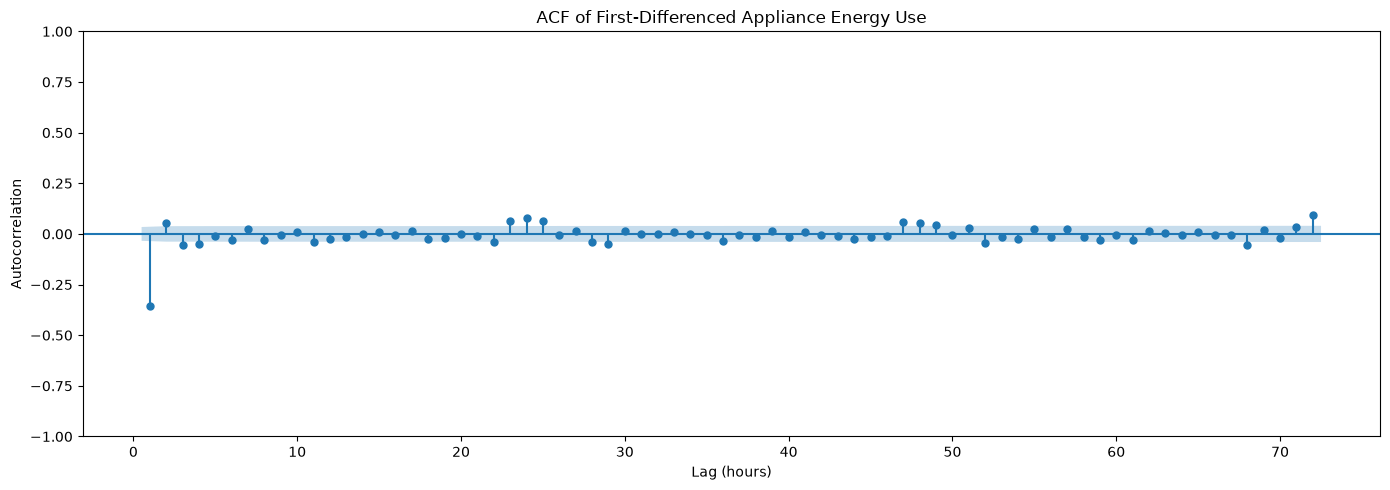

In [40]:
# First-difference ACF

fig, ax = plt.subplots(figsize=(14, 5))

plot_acf(
    first_difference,
    lags=72,
    ax=ax,
    zero=False
)

ax.set_title(
    "ACF of First-Differenced Appliance Energy Use"
)
ax.set_xlabel("Lag (hours)")
ax.set_ylabel("Autocorrelation")

fig.tight_layout()

figure_path = (
    FIGURE_DIR /
    "14_acf_first_difference.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

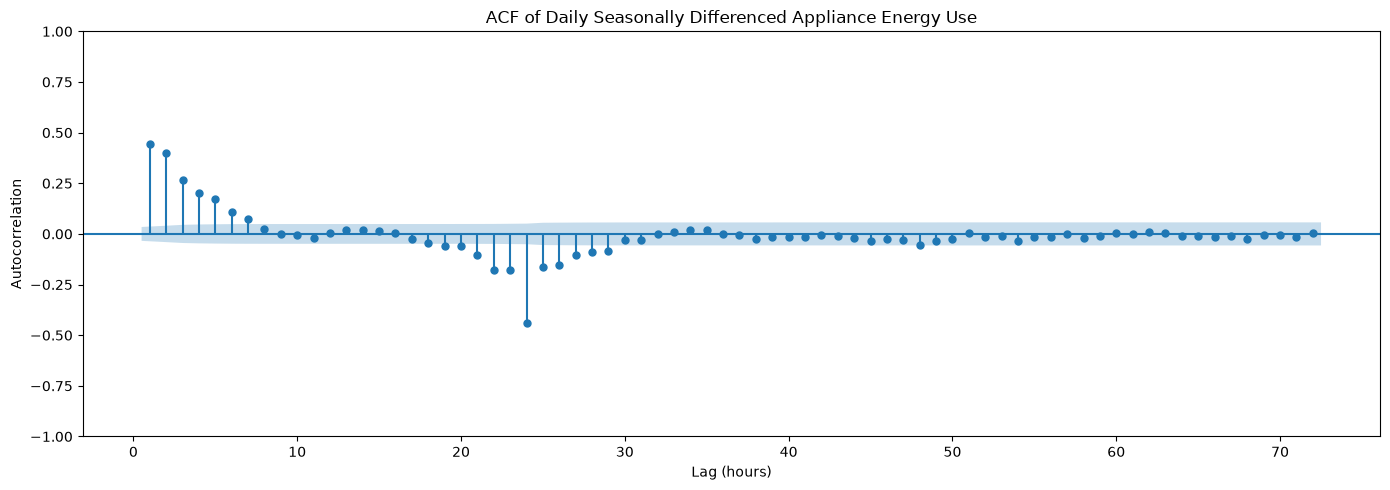

In [41]:
# Seasonal-difference ACF

fig, ax = plt.subplots(figsize=(14, 5))

plot_acf(
    seasonal_difference,
    lags=72,
    ax=ax,
    zero=False
)

ax.set_title(
    "ACF of Daily Seasonally Differenced Appliance Energy Use"
)
ax.set_xlabel("Lag (hours)")
ax.set_ylabel("Autocorrelation")

fig.tight_layout()

figure_path = (
    FIGURE_DIR /
    "15_acf_seasonal_difference.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
# Save stationarity results

METRICS_DIR = (
    PROJECT_ROOT /
    "outputs" /
    "metrics"
)

METRICS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

adf_comparison.to_csv(
    METRICS_DIR /
    "stationarity_adf_results.csv",
    index=False
)

kpss_comparison.to_csv(
    METRICS_DIR /
    "stationarity_kpss_results.csv",
    index=False
)

print(
    "Stationarity test results saved successfully."
)

Stationarity test results saved successfully.


In [43]:
stationarity_summary = pd.DataFrame({
    "Test": ["ADF", "KPSS"],
    "Original Series Conclusion": [
        "Stationary",
        "Stationary"
    ],
    "Evidence": [
        "p < 0.05",
        "p > 0.05"
    ]
})

stationarity_summary

,Test,Original Series Conclusion,Evidence
0,ADF,Stationary,p < 0.05
1,KPSS,Stationary,p > 0.05


In [45]:
stationarity_summary.to_csv(
    METRICS_DIR / "stationarity_summary.csv",
    index=False
)